In [1]:
# CELL 1: Imports
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "utils").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    top_k_accuracy_score,
)
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader
from torchvision import datasets, models


In [2]:
# CELL 2: Configurations
import utils.configs

MODEL_NAME = "resnet101"

print("Model:", MODEL_NAME)
print("Using device:", utils.configs.DEVICE)


Model: resnet101
Using device: cuda


In [3]:
# CELL 3: Inspect raw dataset
from prepare_data import get_class_names

data_path = Path(utils.configs.DATA_DIR)

CLASS_NAMES = get_class_names(data_path)
NUM_CLASSES = len(CLASS_NAMES)

print("Classes found:", CLASS_NAMES)
print("Number of classes found:", NUM_CLASSES)

total_images = 0

for class_name in CLASS_NAMES:
    class_path = data_path / class_name
    image_count = len(list(class_path.glob("*")))
    total_images += image_count
    print(f"{class_name}: {image_count} images")

print(f"\nTotal images: {total_images}")


Classes found: ['kia_carnival', 'kia_ev6', 'kia_seltos', 'kia_sonet']
Number of classes found: 4
kia_carnival: 901 images
kia_ev6: 874 images
kia_seltos: 1070 images
kia_sonet: 815 images

Total images: 3660


# Prepare Train, Validation, and Test Data

The shared splitting logic lives in the project-root `prepare_data.py` file. These notebooks are stored in `notebooks_models/`, but they reuse the same prepared `data_split/` folder for every model.

Shared paths are resolved in `utils.configs`, so data, split data, checkpoints, and final model outputs stay anchored to the project root.


In [4]:
# CELL 4: Prepare split dataset
from prepare_data import split_dataset

split_summary = split_dataset(overwrite=False)


Using existing split folder: C:\Users\rahul\Projects\Automobile Classifier\automobile_classifier_v5\data_split
Pass overwrite=True to rebuild the split.
Split summary:
kia_carnival: train=690, val=86, test=87, total=863
kia_ev6: train=695, val=86, test=88, total=869
kia_seltos: train=856, val=107, test=107, total=1070
kia_sonet: train=652, val=81, test=82, total=815


In [5]:
# CELL 5: Image transforms
from utils.inference import transform_image, transform_train_image

train_transform = lambda image: transform_train_image(image, utils.configs.IMAGE_SIZE)
test_transform = lambda image: transform_image(image, utils.configs.IMAGE_SIZE)


In [6]:
# CELL 6: Create datasets

train_dataset = datasets.ImageFolder(
    root=Path(utils.configs.SPLIT_DIR) / "train",
    transform=train_transform,
)

val_dataset = datasets.ImageFolder(
    root=Path(utils.configs.SPLIT_DIR) / "val",
    transform=test_transform,
)

test_dataset = datasets.ImageFolder(
    root=Path(utils.configs.SPLIT_DIR) / "test",
    transform=test_transform,
)

CLASS_NAMES = train_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

print("Class indices:", train_dataset.class_to_idx)
print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))


Class indices: {'kia_carnival': 0, 'kia_ev6': 1, 'kia_seltos': 2, 'kia_sonet': 3}
Train samples: 2893
Validation samples: 360
Test samples: 364


In [7]:
# CELL 7: Data loaders

train_loader = DataLoader(
    train_dataset,
    batch_size=utils.configs.BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=utils.configs.BATCH_SIZE,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=utils.configs.BATCH_SIZE,
    shuffle=False,
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))


Train batches: 46
Validation batches: 6
Test batches: 6


c:\Users\rahul\AppData\Local\Programs\Python\Python312\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Batch shape: torch.Size([64, 3, 512, 512])


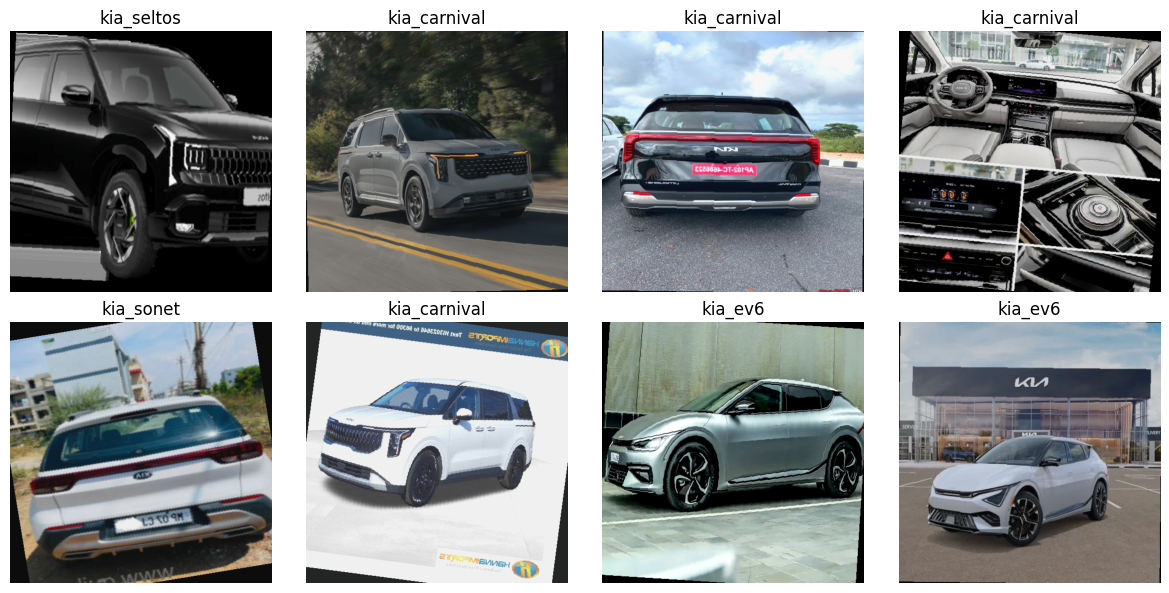

In [8]:
# CELL 8: Visual check

images, labels = next(iter(train_loader))
print("Batch shape:", images.shape)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
sample_count = min(len(images), len(axes.flat))

for i, ax in enumerate(axes.flat):
    ax.axis("off")

    if i >= sample_count:
        continue

    img = images[i].permute(1, 2, 0).numpy()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = np.clip((img * std) + mean, 0, 1)

    ax.imshow(img)
    ax.set_title(CLASS_NAMES[labels[i].item()])

plt.tight_layout()
plt.show()


In [9]:
# CELL 9: Load pretrained ResNet-101

model = models.resnet101(weights=models.ResNet101_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

model = model.to(utils.configs.DEVICE)

print("Classifier head:", model.fc)
print("Model loaded on:", utils.configs.DEVICE)


Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to C:\Users\rahul/.cache\torch\hub\checkpoints\resnet101-cd907fc2.pth
100%|██████████| 171M/171M [00:04<00:00, 36.4MB/s] 


Classifier head: Linear(in_features=2048, out_features=4, bias=True)
Model loaded on: cuda


In [10]:
# CELL 10: Freeze backbone and unfreeze final layers

for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Layer4 and classifier head trainable.")
print(f"Trainable parameters: {trainable_params:,}")


Layer4 and classifier head trainable.
Trainable parameters: 14,972,932


In [11]:
# CELL 11: Loss function and optimizer

loss_fn = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=utils.configs.LEARNING_RATE,
)

print("Loss and optimizer configured.")


Loss and optimizer configured.


# Train

In [12]:
# CELL 12: Training helpers
from utils.train import train_one_epoch, validate
from utils.save_model import save_model


In [ ]:
# CELL 13: Main training loop

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

#Early stopping variables
early_stop_counter = 0
best_val_acc = 0.0
patience = 3

# num_epochs = utils.configs.EPOCHS
num_epochs = 15
checkpoint_folder = utils.configs.get_checkpoint_dir(MODEL_NAME)
checkpoint_folder.mkdir(parents=True, exist_ok=True)

checkpoint_files = list(checkpoint_folder.glob("model_epoch_*.pth"))

if checkpoint_files:
    latest_checkpoint = max(checkpoint_files, key=os.path.getctime)
    print(f"Loading checkpoint: {latest_checkpoint}")
    checkpoint = torch.load(latest_checkpoint, map_location=utils.configs.DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    print("No checkpoints found, starting training from scratch.")

for epoch in range(num_epochs):
    print(f"Epoch [{epoch + 1}/{num_epochs}]")
    print("Training...")
    
    train_loss, train_acc = train_one_epoch(
        model=model,
        dataloader=train_loader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        device=utils.configs.DEVICE,
    )

    val_loss, val_acc = validate(
        model=model,
        dataloader=val_loader,
        loss_fn=loss_fn,
        device=utils.configs.DEVICE,
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    if (epoch+1) % utils.configs.CHECKPOINT_INTERVAL == 0:
        # Save for every 5 epochs
        save_model(
            model=model,
            folder_name=checkpoint_folder,
            model_name=f"model_epoch_{epoch + 1}.pth",
            class_names=CLASS_NAMES,
            num_classes=NUM_CLASSES,
            image_size=utils.configs.IMAGE_SIZE,
            architecture=MODEL_NAME,
        )

    # Early stopping logic
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        early_stop_counter = 0  # Reset counter because we improved!
        # Save best model
        save_model(
            model=model,
            folder_name=checkpoint_folder,
            model_name=f"model_best.pth",
            class_names=CLASS_NAMES,
            num_classes=NUM_CLASSES,
            image_size=utils.configs.IMAGE_SIZE,
            architecture=MODEL_NAME,
        )
    else:
        early_stop_counter += 1 # No improvement, increment the counter
        print(f"No improvement in val accuracy for {early_stop_counter} consecutive epoch(s).")

    # Trigger early stopping
    if early_stop_counter >= patience:
        print(f"Validation accuracy failed to improve for {patience} consecutive epochs. Stopping training.")
        break

    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Accuracy:   {val_acc:.2f}%")
    print("-" * 50)


Loading checkpoint: C:\Users\rahul\Projects\Automobile Classifier\automobile_classifier_v5\models\checkpoints_resnet101\model_epoch_25.pth


C:\Users\rahul\AppData\Local\Temp\ipykernel_19424\956102411.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(latest_checkpoint, map_location=util

KeyboardInterrupt: 

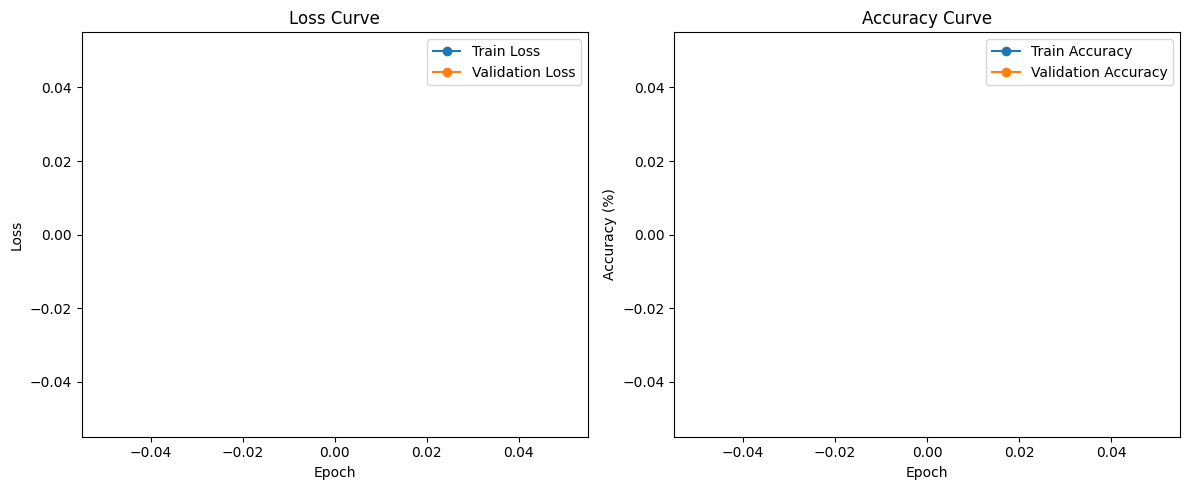

In [16]:
# CELL 14: Plot training curves

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, marker="o", label="Train Loss")
plt.plot(epochs, val_losses, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, marker="o", label="Train Accuracy")
plt.plot(epochs, val_accuracies, marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()


In [17]:
# CELL 15: Test evaluation metrics

model.eval()

all_probabilities = []
all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(utils.configs.DEVICE)
        labels = labels.to(utils.configs.DEVICE)

        outputs = model(images)
        probabilities = F.softmax(outputs, dim=1)
        predictions = torch.argmax(probabilities, dim=1)

        all_probabilities.append(probabilities.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probabilities = np.vstack(all_probabilities)
all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)
class_labels = np.arange(NUM_CLASSES)

accuracy = accuracy_score(all_labels, all_predictions)
balanced = balanced_accuracy_score(all_labels, all_predictions)

precision_macro = precision_score(all_labels, all_predictions, average="macro", zero_division=0)
recall_macro = recall_score(all_labels, all_predictions, average="macro", zero_division=0)
f1_macro = f1_score(all_labels, all_predictions, average="macro", zero_division=0)

precision_micro = precision_score(all_labels, all_predictions, average="micro", zero_division=0)
recall_micro = recall_score(all_labels, all_predictions, average="micro", zero_division=0)
f1_micro = f1_score(all_labels, all_predictions, average="micro", zero_division=0)

precision_weighted = precision_score(all_labels, all_predictions, average="weighted", zero_division=0)
recall_weighted = recall_score(all_labels, all_predictions, average="weighted", zero_division=0)
f1_weighted = f1_score(all_labels, all_predictions, average="weighted", zero_division=0)

print(f"Accuracy Score: {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Balanced Accuracy: {balanced:.4f}")
print(f"Macro Precision: {precision_macro:.4f} | Macro Recall: {recall_macro:.4f} | Macro F1: {f1_macro:.4f}")
print(f"Micro Precision: {precision_micro:.4f} | Micro Recall: {recall_micro:.4f} | Micro F1: {f1_micro:.4f}")
print(f"Weighted Precision: {precision_weighted:.4f} | Weighted Recall: {recall_weighted:.4f} | Weighted F1: {f1_weighted:.4f}")

try:
    if NUM_CLASSES == 2 and len(np.unique(all_labels)) == 2:
        roc_auc = roc_auc_score(all_labels, all_probabilities[:, 1])
        print(f"ROC AUC: {roc_auc:.4f}")
    elif NUM_CLASSES > 2 and len(np.unique(all_labels)) > 1:
        y_onehot = label_binarize(all_labels, classes=class_labels)
        roc_auc = roc_auc_score(
            y_onehot,
            all_probabilities,
            average="macro",
            multi_class="ovr",
        )
        print(f"ROC AUC (macro ovr): {roc_auc:.4f}")
    else:
        print("ROC AUC: skipped because the test set needs at least two classes.")
except Exception as error:
    print("ROC AUC not computed:", error)

if NUM_CLASSES >= 5:
    top5_accuracy = top_k_accuracy_score(
        all_labels,
        all_probabilities,
        k=5,
        labels=class_labels,
    )
    print(f"Top-5 Accuracy: {top5_accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        labels=class_labels,
        target_names=CLASS_NAMES,
        zero_division=0,
    )
)


Accuracy Score: 0.9451 (94.51%)
Balanced Accuracy: 0.9443
Macro Precision: 0.9493 | Macro Recall: 0.9443 | Macro F1: 0.9464
Micro Precision: 0.9451 | Micro Recall: 0.9451 | Micro F1: 0.9451
Weighted Precision: 0.9465 | Weighted Recall: 0.9451 | Weighted F1: 0.9453
ROC AUC (macro ovr): 0.9938

Classification Report:
              precision    recall  f1-score   support

kia_carnival       0.95      0.95      0.95        87
     kia_ev6       0.93      0.94      0.94        88
  kia_seltos       0.91      0.95      0.93       107
   kia_sonet       1.00      0.93      0.96        82

    accuracy                           0.95       364
   macro avg       0.95      0.94      0.95       364
weighted avg       0.95      0.95      0.95       364



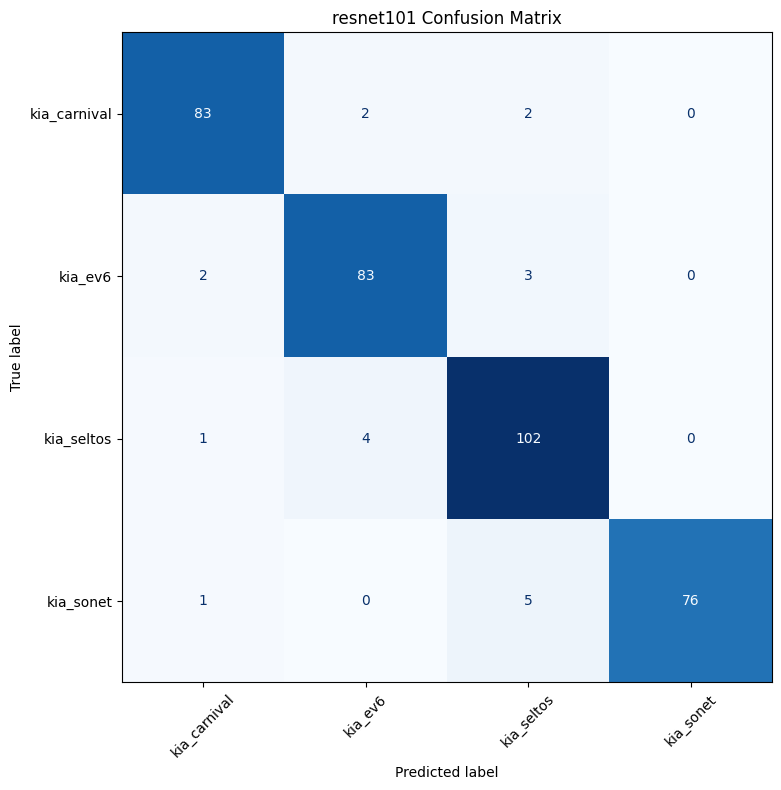

In [18]:
# CELL 16: Confusion matrix

cm = confusion_matrix(all_labels, all_predictions, labels=np.arange(NUM_CLASSES))

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title(f"{MODEL_NAME} Confusion Matrix")
plt.tight_layout()
plt.show()


In [19]:
# CELL 17: Save final model

save_model(
    model=model,
    folder_name=utils.configs.MODEL_DIR,
    model_name=utils.configs.get_model_filename(MODEL_NAME),
    class_names=CLASS_NAMES,
    num_classes=NUM_CLASSES,
    image_size=utils.configs.IMAGE_SIZE,
    architecture=MODEL_NAME,
)


Model saved to C:\Users\rahul\Projects\Automobile Classifier\automobile_classifier_v5\models\final_model_resnet101.pth
